In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import compute_sample_weight
import warnings
import pickle as pkl
from glob import glob
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

In [2]:
%load_ext autoreload
%autoreload 2

In [80]:
files = np.sort(
    glob("../data/generated/pairwise_decoders/stim/recomputed/goodessions/equipop_5bins/*.pkl")
)

In [66]:
# filename = files[-1]
# with open(filename, "rb") as f:
#     data = pkl.load(f)
# region_name = filename.rsplit("_stim")[0].rsplit("_")[-1]

In [82]:
# plot on flatmaps
from iblatlas.plots import plot_swanson_vector
from ibl_info.swanson_plots import add_cbar

In [83]:
# def all_swanson_plots(redundancy, synergy, region_names):
#     max_red = np.max(redundancy[:, 0, :])
#     max_syn = np.max(synergy[:, 0, :])
#     min_red = np.min(redundancy[:, 0, :])
#     min_syn = np.min(synergy[:, 0, :])
#     vmax = np.max([max_red, max_syn])
#     vmin = np.min([min_red, min_syn])

#     fig, ax = plt.subplots(figsize=(16, 8), ncols=4)
#     plot_swanson_vector(
#         region_names,
#         redundancy[:, 0, 0],
#         ax=ax[0],
#         orientation="portrait",
#         annotate=True,
#         annotate_list=region_names,
#         empty_color="silver",
#         linewidth=0.1,
#         mask_color="silver",
#         vmax=max_red,
#         vmin=min_red,
#     )
#     plot_swanson_vector(
#         region_names,
#         redundancy[:, 0, 1],
#         ax=ax[1],
#         orientation="portrait",
#         vmax=max_red,
#         vmin=min_red,
#         annotate=True,
#         annotate_list=region_names,
#         empty_color="silver",
#         linewidth=0.1,
#         mask_color="silver",
#     )
#     plot_swanson_vector(
#         region_names,
#         synergy[:, 0, 0],
#         ax=ax[2],
#         orientation="portrait",
#         vmax=max_syn,
#         vmin=min_syn,
#         annotate=True,
#         annotate_list=region_names,
#         empty_color="silver",
#         linewidth=0.1,
#         mask_color="silver",
#     )
#     plot_swanson_vector(
#         region_names,
#         synergy[:, 0, 1],
#         ax=ax[3],
#         orientation="portrait",
#         vmax=max_syn,
#         vmin=min_syn,
#         annotate=True,
#         annotate_list=region_names,
#         empty_color="silver",
#         linewidth=0.1,
#         mask_color="silver",
#     )

#     for idx in range(4):
#         ax[idx].axis("off")

#     cbar_kwargs = {"shrink": 0.5, "aspect": 12, "pad": 0.025}
#     cax = add_cbar(
#         "viridis", max_red, min_red, ax[0], "Information(in bits)", cbar_kwargs=cbar_kwargs
#     )
#     cax = add_cbar(
#         "viridis", max_red, min_red, ax[1], "Information(in bits)", cbar_kwargs=cbar_kwargs
#     )
#     cax = add_cbar(
#         "viridis", max_syn, min_syn, ax[2], "Information(in bits)", cbar_kwargs=cbar_kwargs
#     )
#     cax = add_cbar(
#         "viridis", max_syn, min_syn, ax[3], "Information(in bits)", cbar_kwargs=cbar_kwargs
#     )

#     ax[0].set_title("Redundant-Congruent")
#     ax[1].set_title("Redundant-Incongruent")

#     ax[2].set_title("Synergy-Congruent")
#     ax[3].set_title("Synergy-Incongruent")

In [84]:
# accuracies

In [85]:
from ibl_info.decoder_utils import (
    congregate_data,
    collapse_animal,
    individual_region_means,
    pids_per_region,
)

from ibl_info.decoder_utils import plot_all_rsis, plot_all_decompositions, plot_regions_rsi

In [86]:
rsi_congruent, rsi_incongruent, redundancy, synergy, region_names = congregate_data(files, "stim")

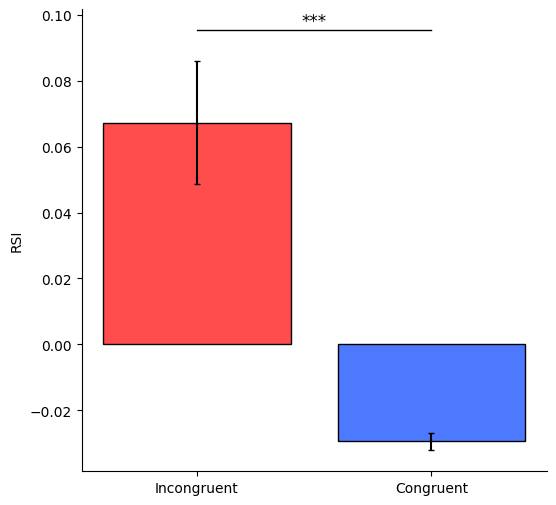

In [87]:
plot_all_rsis(rsi_congruent, rsi_incongruent)

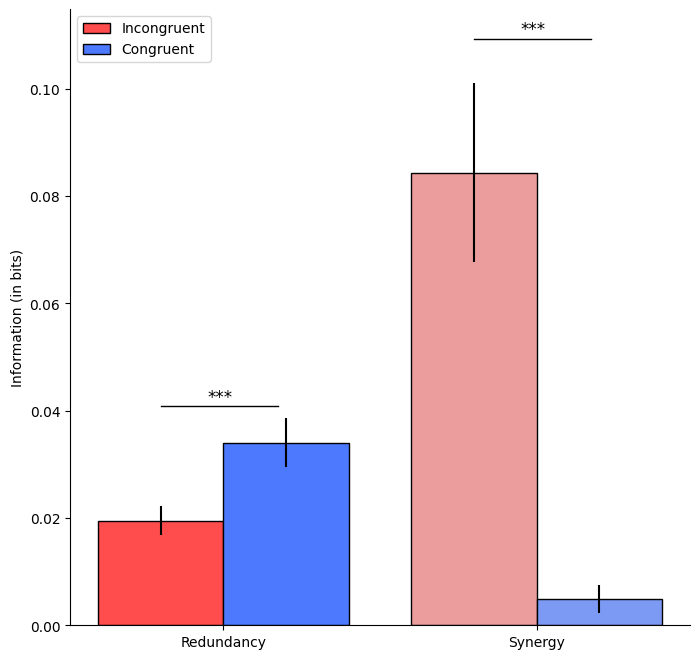

In [88]:
plot_all_decompositions(redundancy, synergy)

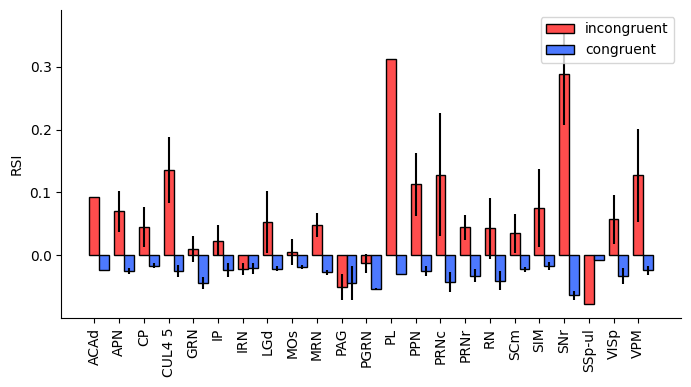

In [89]:
plot_regions_rsi(rsi_incongruent, rsi_congruent, region_names)

In [61]:
def accuracy_per_region(fx):
    mean_accuracies = []
    for k in fx:
        animal = fx[k]["decoding_results"]
        accuracies = []
        for idx in range(len(animal)):
            aca = animal[idx]["accuracy_A"]
            acb = animal[idx]["accuracy_B"]
            accuracies.append(np.mean([aca, acb]))
        mean_accuracies.append(np.mean(accuracies))

    return mean_accuracies

In [62]:
def get_mean_accuracies(files, epoch):

    info_dict = {}
    for idx in range(len(files)):
        filename = files[idx]
        with open(filename, "rb") as f:
            data = pkl.load(f)

        mean_accuracies = accuracy_per_region(data)
        region_name = filename.rsplit(f"_{epoch}")[0].rsplit("_")[-1]
        info_dict[region_name] = mean_accuracies

    return info_dict

In [64]:
accuracies = get_mean_accuracies(files, "stim")

KeyError: 'decoding_results'

In [45]:
mean_per_region = []

for k in accuracies.keys():
    if len(accuracies[k]) == 0:
        continue
    mean_per_region.append(
        [np.mean(accuracies[k]), np.std(accuracies[k]) / np.sqrt(len(accuracies[k]))]
    )

In [46]:
mean_per_region = np.asarray(mean_per_region)

In [47]:
individual_values = []

for x in accuracies.keys():
    if len(accuracies[x]) == 0:
        continue
    else:
        individual_values.append(accuracies[x])

Text(0, 0.5, 'Balanced accuracy')

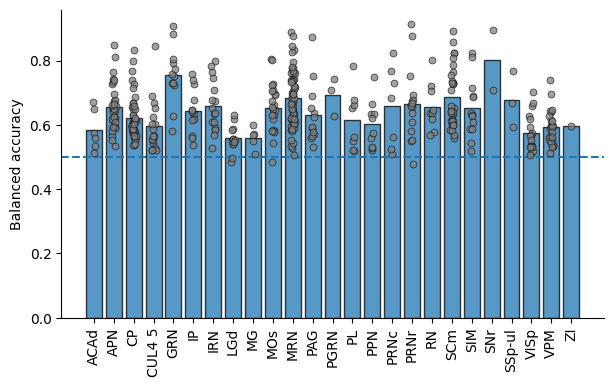

In [48]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.stripplot(individual_values, color="grey", alpha=0.75, edgecolor="k", linewidth=0.5)
sns.despine()
ax.bar(np.arange(len(mean_per_region)), mean_per_region[:, 0], edgecolor="k", alpha=0.75)
ax.axhline(0.5, linestyle="--")
ax.set_xticks(np.arange(len(region_names)), region_names, rotation=90)
ax.set_ylabel("Balanced accuracy")

In [9]:
# run recomputation
filename = "../data/generated/pairwise_decoders/goodsessions_3bins/selective_decomposition_CUL4 5_stim_decoder_alldata_goodsessions_projections.pkl"

In [13]:
from ibl_info.decoder_utils import recompute, load_pickle
from ibl_info.decoder_utils import individual_region_sems

In [11]:
data = load_pickle(filename)

In [31]:
recomputed_data = recompute(data, n_bins=5)

Animals: 100%|██████████| 4/4 [00:13<00:00,  3.36s/it]


In [22]:
rsi_congruent_means, rsi_incongruent_means, redundancy_means, synergy_means = (
    individual_region_means(data)
)
rsi_congruent_sems, rsi_incongruent_sems, redundancy_sems, synergy_sems = individual_region_sems(
    data
)

In [32]:
(
    recom_rsi_congruent_means,
    recom_rsi_incongruent_means,
    recom_redundancy_means,
    recom_synergy_means,
) = individual_region_means(recomputed_data)
recom_rsi_congruent_sems, recom_rsi_incongruent_sems, recom_redundancy_sems, recom_synergy_sems = (
    individual_region_sems(recomputed_data)
)